In [1]:
!git clone https://github.com/pentakll4002/IS403_Q13
!pip install category_encoders

Cloning into 'IS403_Q13'...
remote: Enumerating objects: 747, done.
remote: Counting objects: 100% (747/747), done.
remote: Compressing objects: 100% (478/478), done.
remote: Total 747 (delta 207), reused 700 (delta 169), pack-reused 0 (from 0)
Receiving objects: 100% (747/747), 16.45 MiB | 26.57 MiB/s, done.
Resolving deltas: 100% (207/207), done.
Filtering content: 100% (6/6), 1.44 GiB | 30.66 MiB/s, done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [2]:
!nvidia-smi


Sun Nov 30 17:00:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
import category_encoders as TargetEncoder

warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df_1 = pd.read_csv(r"IS403_Q13/data/Fraudulent_E-Commerce_Transaction_Data.csv")
df_2 = pd.read_csv(r"IS403_Q13/data/Fraudulent_E-Commerce_Transaction_Data_2.csv")

In [4]:
df = pd.concat([df_1, df_2], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1496586 non-null  object 
 1   Customer ID         1496586 non-null  object 
 2   Transaction Amount  1496586 non-null  float64
 3   Transaction Date    1496586 non-null  object 
 4   Payment Method      1496586 non-null  object 
 5   Product Category    1496586 non-null  object 
 6   Quantity            1496586 non-null  int64  
 7   Customer Age        1496586 non-null  int64  
 8   Customer Location   1496586 non-null  object 
 9   Device Used         1496586 non-null  object 
 10  IP Address          1496586 non-null  object 
 11  Shipping Address    1496586 non-null  object 
 12  Billing Address     1496586 non-null  object 
 13  Is Fraudulent       1496586 non-null  int64  
 14  Account Age Days    1496586 non-null  int64  
 15  Transaction Hou

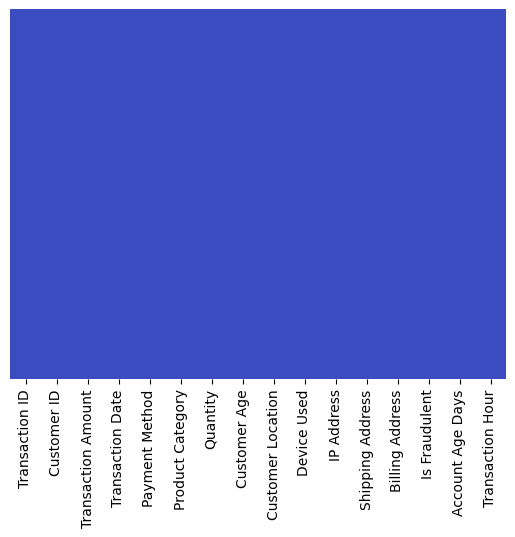

In [ ]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap="coolwarm")
plt.show()

In [ ]:
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06
mean,2.268093e+02,3.000235e+00,3.451284e+01,5.015415e-02,1.796308e+02,1.128663e+01
std,2.705831e+02,1.414814e+00,1.000323e+01,2.182630e-01,1.068726e+02,6.976067e+00
min,1.000000e+01,1.000000e+00,-1.600000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,6.862000e+01,2.000000e+00,2.800000e+01,0.000000e+00,8.600000e+01,5.000000e+00
50%,1.517600e+02,3.000000e+00,3.500000e+01,0.000000e+00,1.790000e+02,1.100000e+01
75%,2.960500e+02,4.000000e+00,4.100000e+01,0.000000e+00,2.720000e+02,1.700000e+01
max,1.270175e+04,5.000000e+00,8.600000e+01,1.000000e+00,3.650000e+02,2.300000e+01


In [8]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Date', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'IP Address',
       'Shipping Address', 'Billing Address', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour'],
      dtype='object')

In [ ]:
print(len(df.columns))

16


In [ ]:
# plt.figure(figsize=(10, 50))

# for i in range(len(df.columns)):
#     plt.subplot(17, 1, i + 1)
#     sns.histplot(df[df.columns[i]], kde=True, color="g")
#     plt.title(df.columns[i])

# plt.tight_layout()
# plt.show()

In [5]:
# xử lý data tuổi âm
df = df[df['Customer Age']>0]

In [6]:
import datetime
# Xử lý ngày tháng năm giao dịch
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Transaction Date'] = df['Transaction Date'].apply(lambda x: x.timestamp())

#df.drop(columns=["Transaction Date"], inplace=True)

In [11]:
df['Transaction Date']

,Transaction Date
0,1.708409e+09
1,1.708849e+09
2,1.710733e+09
3,1.710622e+09
4,1.705295e+09
...,...
1496581,1.706286e+09
1496582,1.708881e+09
1496583,1.711670e+09
1496584,1.707478e+09


In [7]:
cols_to_drop = [
    "Transaction ID",
    "Transaction Hour"
    "Customer ID",
    "Shipping Address",
    "Billing Address"
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [8]:
categorical_features = ["Payment Method", "Product Category", "Customer Location", "Device Used"]
target = "Is Fraudulent"


In [12]:
df

,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Is Fraudulent,Account Age Days,Transaction Hour
0,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,1.708409e+09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,0,30,5
1,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,1.708849e+09,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,0,72,8
2,1bac88d6-4b22-409a-a06b-425119c57225,134.19,1.710733e+09,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,0,63,3
3,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,1.710622e+09,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,0,124,20
4,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,1.705295e+09,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,0,158,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496581,98a3d94c-dc9a-4525-b273-e6ffe54cc5a4,53.73,1.706286e+09,PayPal,toys & games,5,32,Rebeccafurt,tablet,173.97.197.128,0,363,16
1496582,b3429f52-8b27-46b5-914c-4accd989edb4,47.42,1.708881e+09,credit card,clothing,4,41,Nataliefort,desktop,133.222.22.48,0,296,17
1496583,066e25c9-4420-4224-bc3f-1a462708090e,1045.23,1.711670e+09,bank transfer,health & beauty,1,9,East Shannonville,tablet,206.133.237.168,0,329,23
1496584,cde96e9c-f562-4b8c-8fa8-f356f474232b,34.25,1.707478e+09,debit card,home & garden,2,39,Lake Nicole,mobile,16.204.137.130,0,347,11


In [42]:
from cuml.manifold import UMAP

In [55]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.decomposition import TruncatedSVD

import numpy as np
import pandas as pd

def hash_location(X):
    # X là dataframe với 1 cột "Customer Location"
    # Trả về list các dict [{'Customer Location': value}, ...]
    data = X.iloc[:, 0].astype(str)
    dicts = [{ "Customer Location": v } for v in data]
    hasher = FeatureHasher(n_features=128, input_type="dict")
    return hasher.transform(dicts)

preprocess = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown='ignore', sparse_output=True),
         ['Payment Method', 'Product Category', 'Device Used']),

        ("hash", FunctionTransformer(hash_location, validate=False),
         ['Customer Location']),

        ("num", StandardScaler(with_mean=False),
         df.select_dtypes(include=[np.number]).columns.tolist())
    ],
    remainder="drop"
)

pipeline = Pipeline([ ('preprocess', preprocess),
                      ('pca', PCA(n_components=50, random_state=42)),
                      ('umap', UMAP( n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', random_state=42, init='random' )) ])


[2025-11-30 17:48:18.775] [CUML] [info] build_algo set to brute_force_knn because random_state is given


In [56]:
X_embedded = pipeline.fit_transform(df.drop(columns='Customer ID'))

In [15]:
!pip install kneed

Optimal number of clusters (Elbow): 5


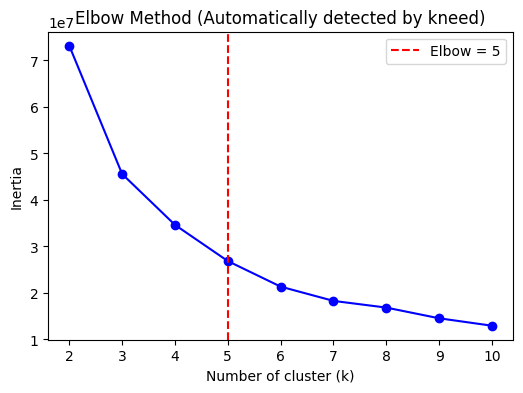

In [57]:
from cuml.cluster import KMeans
from kneed import KneeLocator
import cupy as cp
import matplotlib.pyplot as plt

# Chuyển dữ liệu sang GPU (nếu chưa)
X_gpu = cp.asarray(X_embedded)

inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        max_iter=300,
        init="k-means++"
    )
    kmeans.fit(X_gpu)
    inertias.append(float(kmeans.inertia_))  # inertia_ là cupy scalar → chuyển về float

# Tìm "elbow" bằng KneeLocator
kl = KneeLocator(K, inertias, curve="convex", direction="decreasing")
optimal_k = kl.elbow

print(f"Optimal number of clusters (Elbow): {optimal_k}")

plt.figure(figsize=(6,4))
plt.plot(K, inertias, 'bo-')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Elbow = {optimal_k}')
plt.xlabel('Number of cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Automatically detected by kneed)')
plt.legend()
plt.show()

In [58]:
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    max_iter=300,
    init="k-means++"
)

kmeans_final.fit(X_gpu)

# labels_ là cupy array → có thể dùng trực tiếp hoặc chuyển về numpy
labels = cp.asnumpy(kmeans_final.labels_)

In [59]:
data_clt = kmeans_final.cluster_centers_.shape
print(f"Shape of cluster centers: {data_clt}")

Shape of cluster centers: (5, 2)


In [60]:
cluster_centers = pd.DataFrame(
    data = cp.asnumpy(kmeans_final.cluster_centers_),
    columns = [f"PCA_{i+1}" for i in range(X_gpu.shape[1])]
)
print("\nCluster Centers:")
cluster_centers


Cluster Centers:


,PCA_1,PCA_2
0,-6.468323,0.491306
1,-2.042577,8.957231
2,6.742270,-4.386705
3,-3.395926,-7.833471
4,6.050892,3.944387


In [31]:
labels.shape

(1496056,)

In [22]:
print(labels.max())
print(labels.min())

4
0


In [61]:
y_kmeans = kmeans.fit_predict(X_gpu)
y_kmeans

array([5, 4, 7, ..., 6, 0, 5], dtype=int32)

In [62]:
df_cluster = pd.DataFrame(
    cp.asnumpy(X_gpu),
    columns=[f"PCA_{i+1}" for i in range(X_gpu.shape[1])]
)
df_cluster['cluster'] = labels

print("DataFrame with cluster labels:")
df_cluster.head()

DataFrame with cluster labels:


,PCA_1,PCA_2,cluster
0,-6.060108,-7.572749,3
1,-10.394352,2.759995,0
2,0.934890,9.762268,1
3,-2.727157,-1.255223,0
4,-8.434919,-5.812700,3


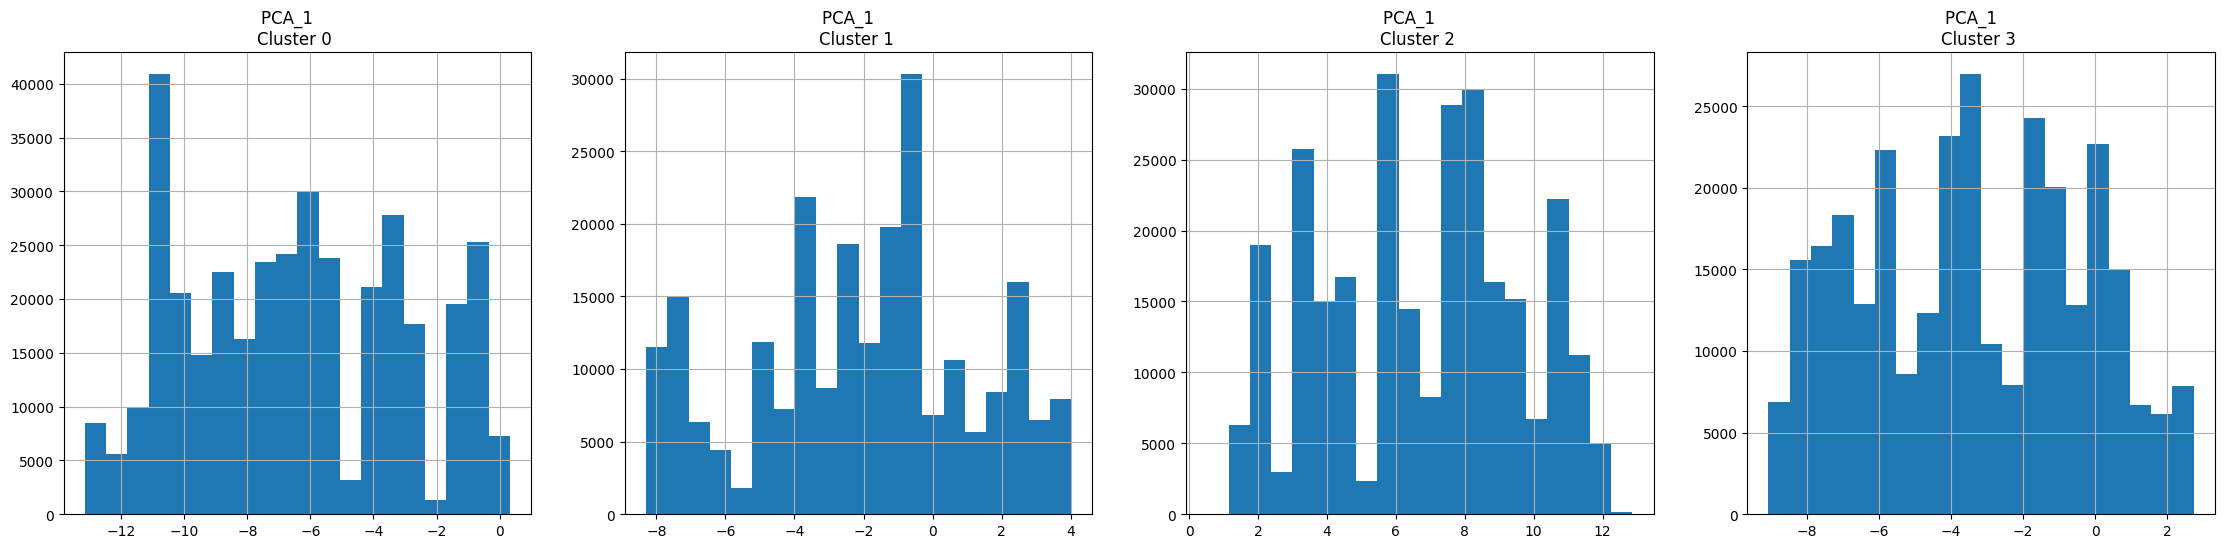

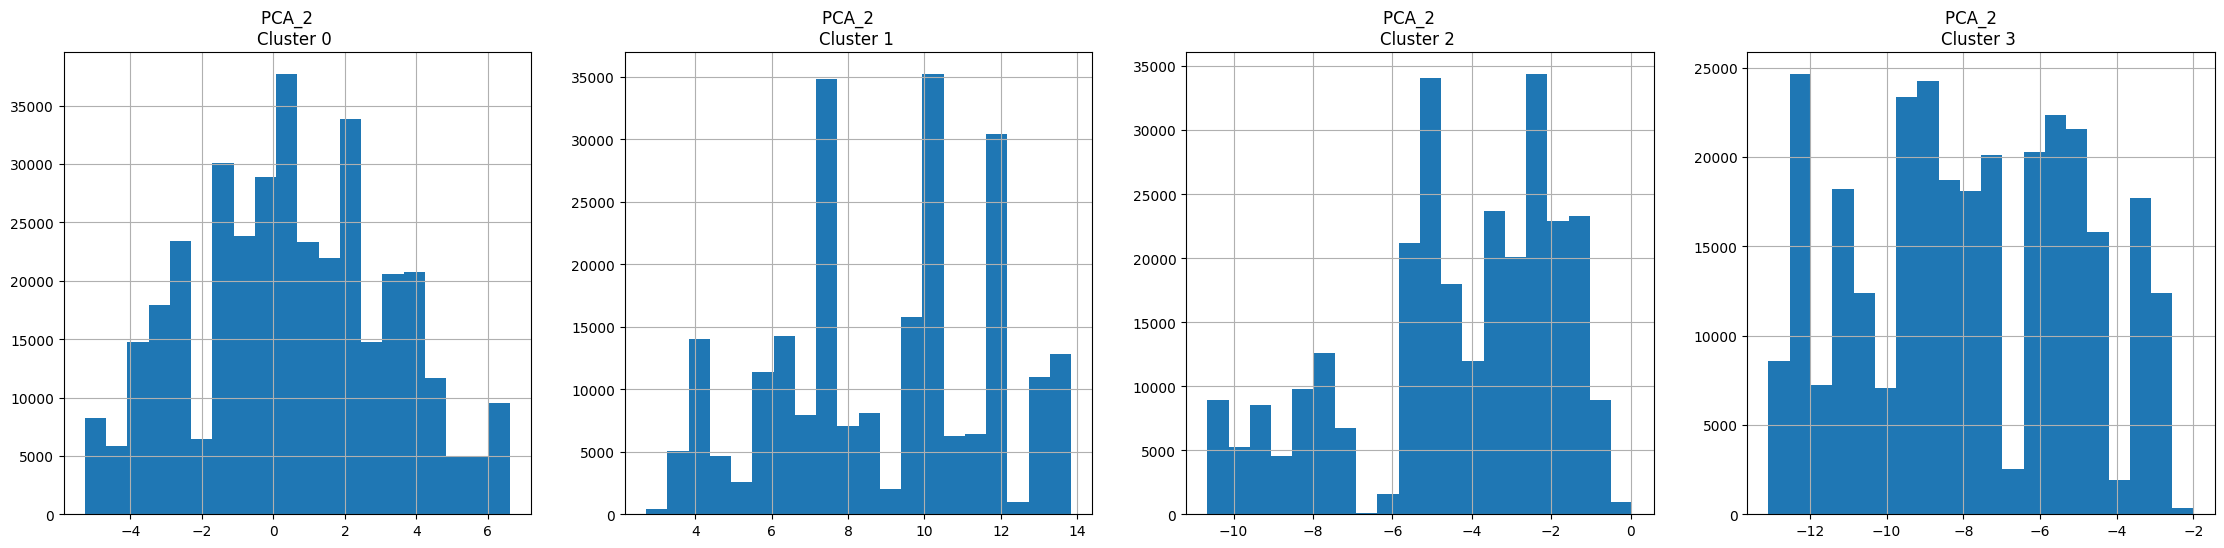

In [63]:
# Plot the histogram of various clusters
for i in df_cluster.columns[:-1]:
    plt.figure(figsize = (35, 6))
    for j in range(4):
        plt.subplot(1,5,j+1)
        cluster = df_cluster[df_cluster['cluster'] == j]
        cluster[i].hist(bins = 20)
        plt.title('{}    \nCluster {} '.format(i,j))

    plt.show()


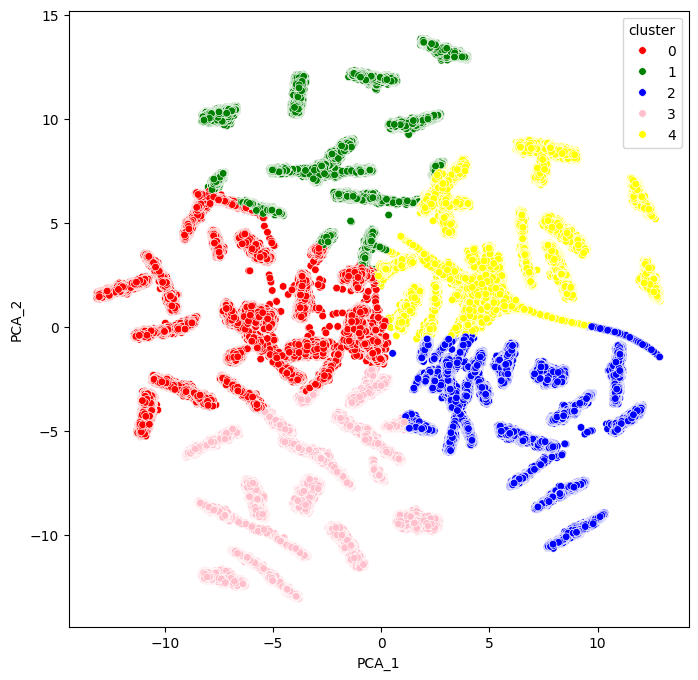

In [64]:
plt.figure(figsize=(8,8))
sns.scatterplot(
    x="PCA_1", y="PCA_2",
    hue="cluster",
    data=df_cluster,
    palette=['red','green','blue','pink','yellow','orange'],
    s=30
)
plt.show()
